# Day 20 — Global Change
### #30DayChartChallenge | April 2026

**The Solar Learning Curve.** Between 2000 and 2024, global solar PV capacity grew from 1.2 GW to 1,866 GW — a ~1,500× increase — while module costs collapsed from $6.29/W to $0.26/W (a 96% drop). When you plot cost against cumulative deployment on a log-log scale, the line is nearly straight: every doubling of installed capacity has cut costs by ~25%. That's Wright's Law in action, applied to the chemistry of crystalline silicon.

**Data:** [Our World in Data](https://ourworldindata.org/grapher/solar-pv-prices) — module prices (Nemet 2009 + IRENA + BloombergNEF) and global installed capacity (IRENA / Ember)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 13, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read combined Wright's Law dataset ----------------------------------------
# OWID's combined cost + cumulative-capacity dataset, 1975–2024 (50 years).
# Capacity in MW; module cost in real 2024 USD per watt.

raw <- read.csv("../../data/day_20/owid_experience_curve.csv",
                stringsAsFactors = FALSE) %>%
  rename(year = Year,
         cost_per_w = Solar.PV.module.cost,
         capacity_mw = Cumulative.installed.solar.PV.capacity)

df <- raw %>%
  select(year, cost_per_w, capacity_mw) %>%
  mutate(capacity_gw = capacity_mw / 1000)

# Wright's Law: log-log linear fit over the FULL 1975–2024 series
fit <- lm(log(cost_per_w) ~ log(capacity_mw), data = df)
slope <- coef(fit)[2]
learning_rate <- (1 - 2^slope) * 100   # cost reduction per doubling

y_first <- df %>% filter(year == min(year))
y_last  <- df %>% filter(year == max(year))

cat("Years covered:", min(df$year), "to", max(df$year),
    "(", nrow(df), "data points)\n")
cat("Cost", min(df$year), ":", round(y_first$cost_per_w, 2),
    "$/W \u2192", max(df$year), ":", round(y_last$cost_per_w, 2), "$/W\n")
cat("Cost reduction:",
    round((1 - y_last$cost_per_w / y_first$cost_per_w) * 100, 2), "%\n")
cat("Capacity", min(df$year), ":", round(y_first$capacity_mw, 2),
    "MW \u2192", max(df$year), ":",
    format(round(y_last$capacity_mw), big.mark = ","), "MW\n")
cat("Capacity growth:",
    format(round(y_last$capacity_mw / y_first$capacity_mw), big.mark = ","),
    "\u00d7\n")
cat("Wright's Law learning rate:", round(learning_rate, 1),
    "% cost decline per doubling of capacity\n")

Years covered: 1975 to 2024 ( 50 data points)


Cost 1975 : 128.27 $/W → 2024 : 0.26 $/W


Cost reduction: 99.8 %


Capacity 1975 : 0.54 MW → 2024 : 1,852,359 MW


Capacity growth: 3,430,294 ×


Wright's Law learning rate: 23.5 % cost decline per doubling of capacity


Warning message in annotate("label", x = 50000, y = 60, label = paste0("Wright's Law\n", :
"Ignoring unknown parameters: `label.size`"


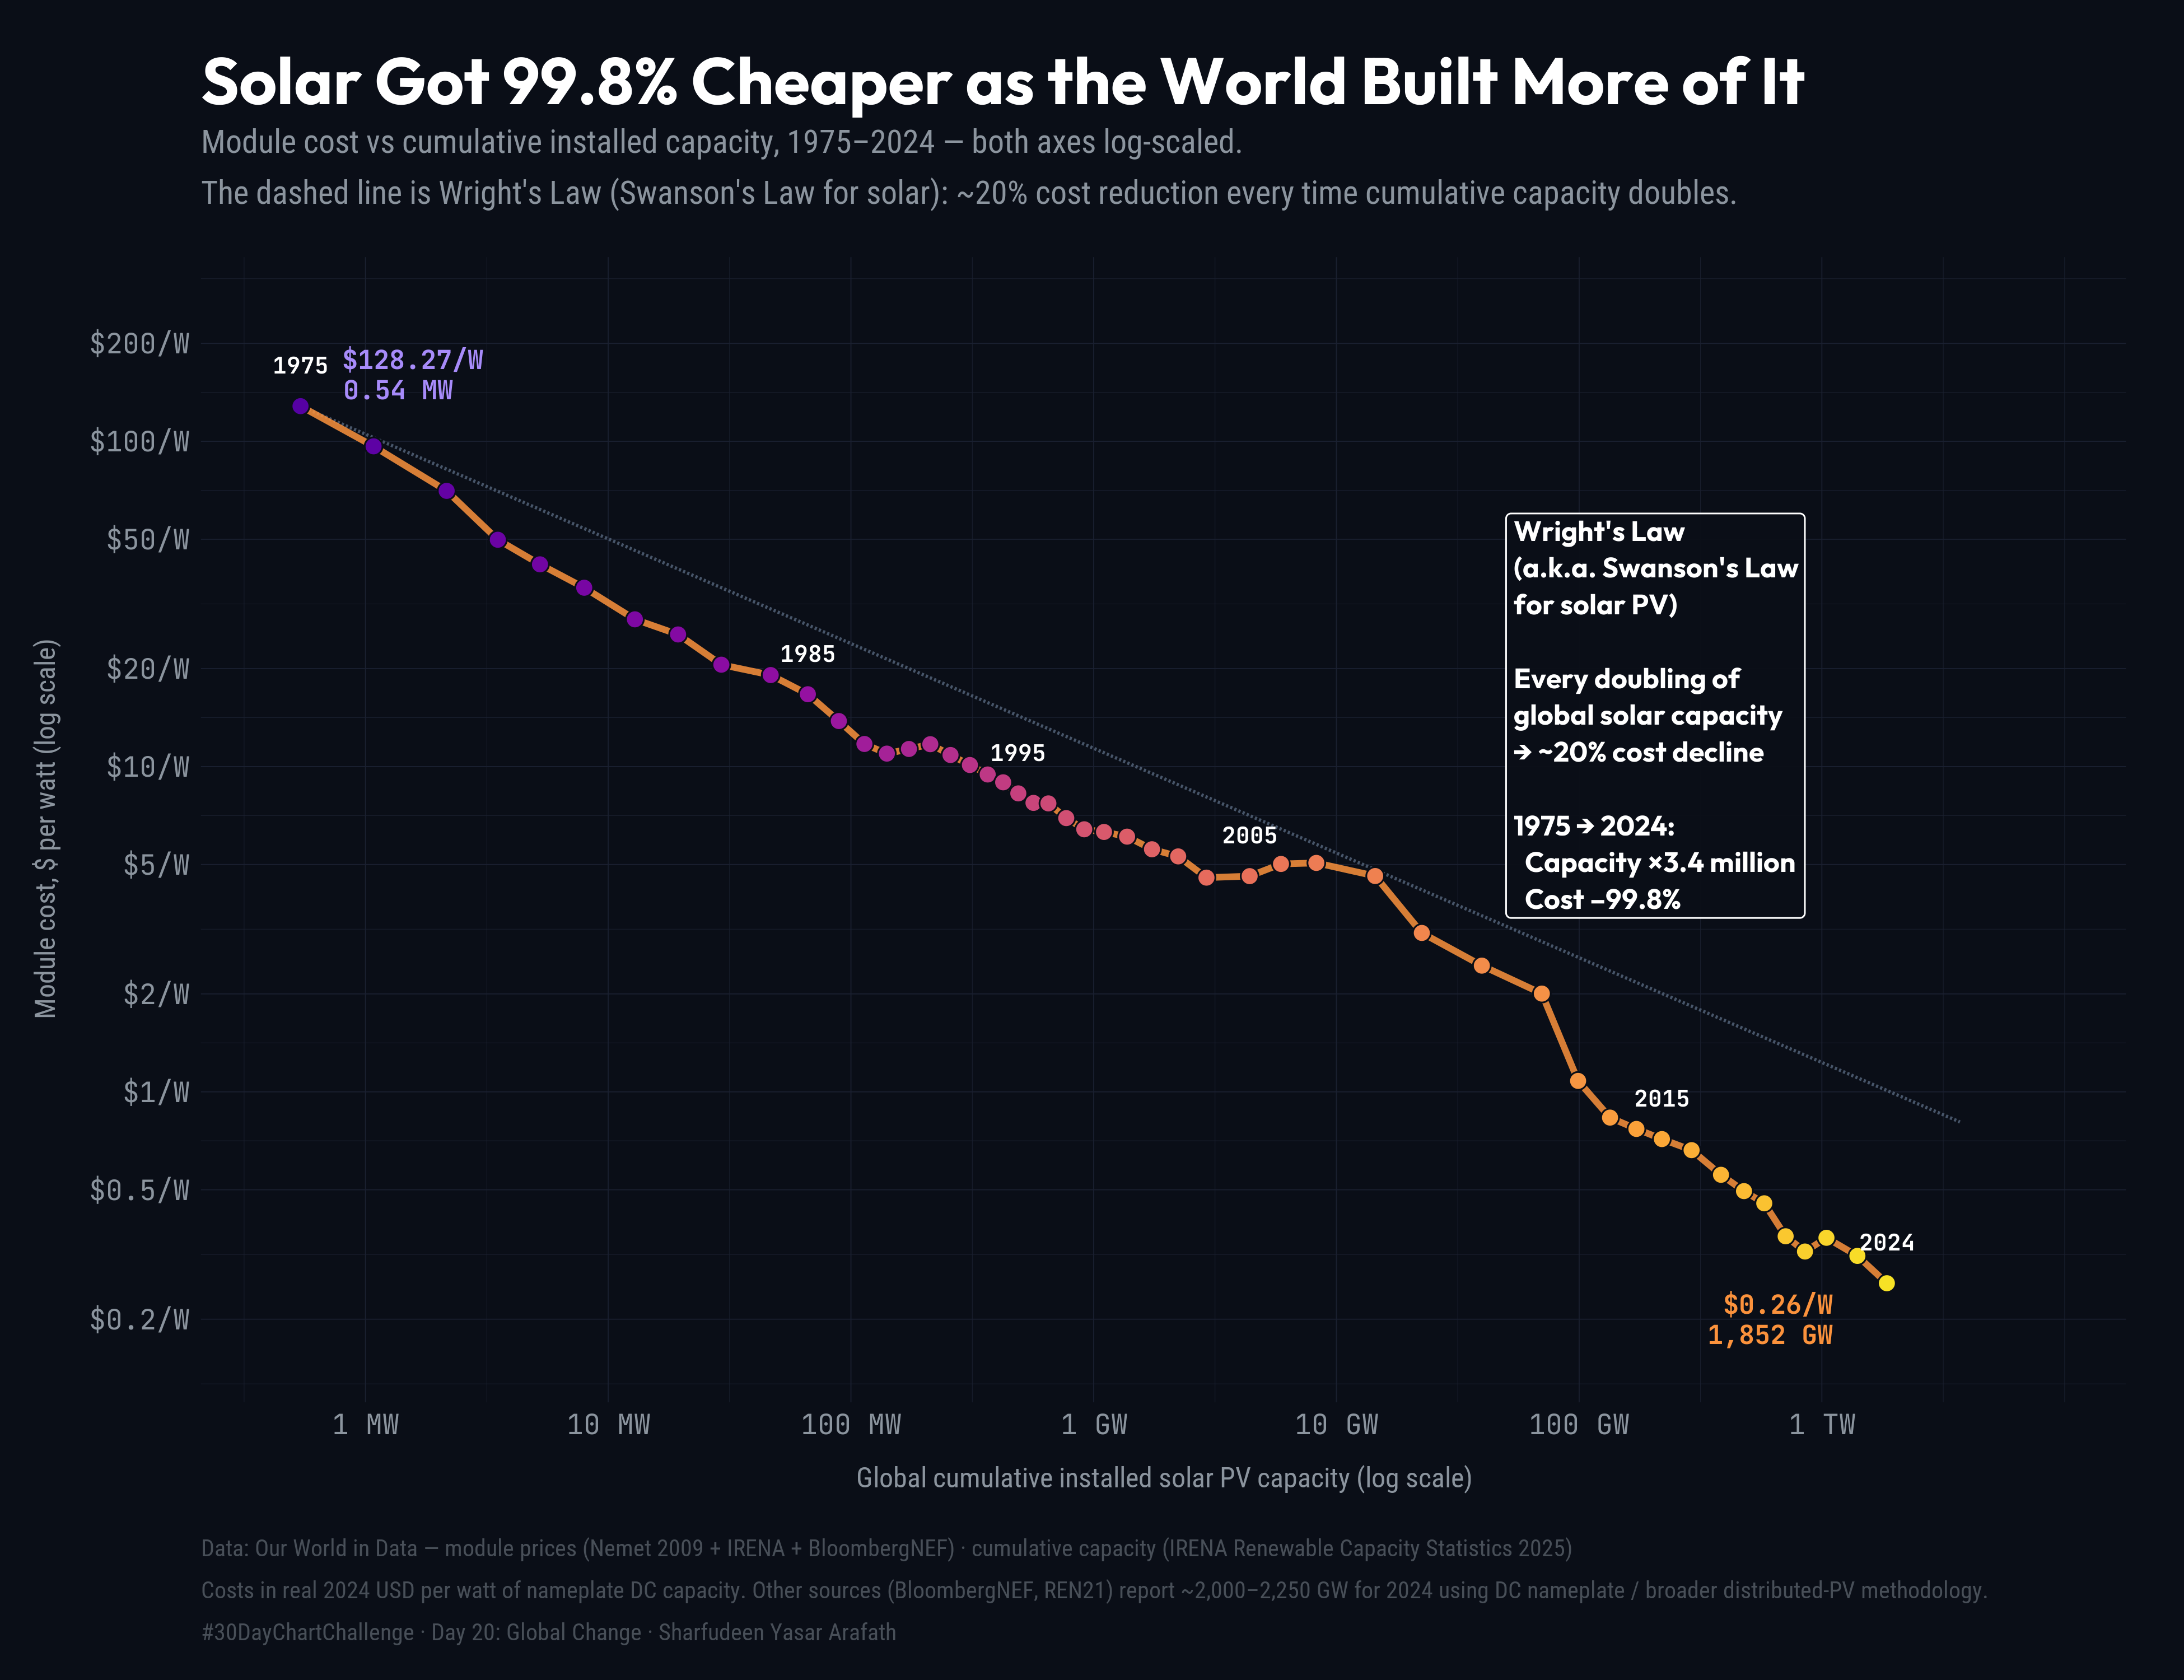

In [4]:
# — build the plot ------------------------------------------------------------

bg <- "#0a0e17"; txt <- "#E6EDF3"; txt_dim <- "#8B949E"
txt_cap <- "#484F58"; grid_col <- "#1a2030"

# Years to label along the curve
label_years <- c(1975, 1985, 1995, 2005, 2015, 2024)
label_pts <- df %>% filter(year %in% label_years)

# Canonical Wright's Law (Swanson's Law) reference line: 20% cost reduction
# per doubling of cumulative capacity. Anchor at the 1975 starting point.
swanson_lr  <- 0.20
ref_slope   <- log2(1 - swanson_lr)              # = log2(0.80) = -0.3219
ref_x       <- 10^seq(log10(y_first$capacity_mw),
                      log10(y_last$capacity_mw * 2),
                      length.out = 100)
ref_line    <- data.frame(
  capacity_mw = ref_x,
  cost_per_w  = y_first$cost_per_w *
                (ref_x / y_first$capacity_mw)^ref_slope
)

p <- ggplot(df, aes(x = capacity_mw, y = cost_per_w)) +
  # Reference line: canonical 20% Swanson's Law slope
  geom_line(data = ref_line, aes(x = capacity_mw, y = cost_per_w),
            color = "#475569", linetype = "dashed", linewidth = 0.5,
            inherit.aes = FALSE) +

  # Connected scatter coloured by year
  geom_path(color = "#fb923c", linewidth = 1.0, alpha = 0.85) +
  geom_point(aes(fill = year), shape = 21, size = 3.2,
             color = "#0a0e17", stroke = 0.4) +

  # Year labels at milestone points
  geom_text(data = label_pts,
    aes(label = year),
    family = "jetbrains", fontface = "bold", size = 3.5,
    color = "#FFFFFF", nudge_y = 0.10, vjust = 0) +

  # Endpoint annotations
  annotate("text", x = y_first$capacity_mw * 1.5, y = y_first$cost_per_w * 1.05,
    label = paste0("$", round(y_first$cost_per_w, 2), "/W\n",
                   round(y_first$capacity_mw, 2), " MW"),
    family = "jetbrains", fontface = "bold", size = 4,
    color = "#a78bfa", hjust = 0, vjust = 0, lineheight = 0.95) +
  annotate("text", x = y_last$capacity_mw * 0.6, y = y_last$cost_per_w * 0.65,
    label = paste0("$", round(y_last$cost_per_w, 2), "/W\n",
                   format(round(y_last$capacity_gw), big.mark = ","), " GW"),
    family = "jetbrains", fontface = "bold", size = 4,
    color = "#fb923c", hjust = 1, vjust = 0, lineheight = 0.95) +

  # Big takeaway callout
  annotate("label", x = 50000, y = 60,
    label = paste0(
      "Wright's Law\n",
      "(a.k.a. Swanson's Law\n",
      "for solar PV)\n",
      "\n",
      "Every doubling of\n",
      "global solar capacity\n",
      "\u2192 ~20% cost decline\n",
      "\n",
      "1975 \u2192 2024:\n",
      "  Capacity \u00d73.4 million\n",
      "  Cost \u201399.8%"),
    family = "outfit", fontface = "bold", size = 4.2,
    color = "#FFFFFF", fill = "#0a0e17EE", label.size = 0,
    lineheight = 1.1, hjust = 0, vjust = 1) +

  scale_fill_viridis_c(option = "plasma", guide = "none",
                       begin = 0.15, end = 0.95) +
  scale_x_log10(
    breaks = c(1, 10, 100, 1000, 10000, 100000, 1000000),
    labels = c("1 MW", "10 MW", "100 MW", "1 GW", "10 GW", "100 GW", "1 TW"),
    expand = expansion(mult = c(0.06, 0.10))) +
  scale_y_log10(
    breaks = c(0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200),
    labels = function(y) paste0("$", y, "/W"),
    expand = expansion(mult = c(0.06, 0.12))) +

  labs(
    title = "Solar Got 99.8% Cheaper as the World Built More of It",
    subtitle = paste0(
      "Module cost vs cumulative installed capacity, 1975\u20132024 \u2014 both axes log-scaled.\n",
      "The dashed line is Wright's Law (Swanson's Law for solar): ~20% cost reduction every time cumulative capacity doubles."
    ),
    x = "Global cumulative installed solar PV capacity (log scale)",
    y = "Module cost, $ per watt (log scale)",
    caption = paste0(
      "Data: Our World in Data \u2014 module prices (Nemet 2009 + IRENA + BloombergNEF) \u00b7 ",
      "cumulative capacity (IRENA Renewable Capacity Statistics 2025)\n",
      "Costs in real 2024 USD per watt of nameplate DC capacity. ",
      "Other sources (BloombergNEF, REN21) report ~2,000\u20132,250 GW for 2024 using DC nameplate / broader distributed-PV methodology.\n",
      "#30DayChartChallenge \u00b7 Day 20: Global Change \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 28,
      color = "#FFFFFF", margin = margin(t = 10, b = 5)),
    plot.subtitle = element_text(size = 14, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 20)),
    plot.caption = element_text(size = 10, hjust = 0, color = txt_cap,
      lineheight = 1.5, margin = margin(t = 20)),
    axis.text = element_text(size = 12, color = txt_dim,
      family = "jetbrains"),
    axis.title.x = element_text(size = 12, color = txt_dim,
      margin = margin(t = 12)),
    axis.title.y = element_text(size = 12, color = txt_dim,
      margin = margin(r = 12)),
    panel.grid.major = element_line(color = grid_col, linewidth = 0.15),
    panel.grid.minor = element_line(color = grid_col, linewidth = 0.08),
    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 25, 15, 15)
  )

p

In [5]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_20_global_change.png",
       plot = p, width = 13, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_20_global_change.png\n")

Done — saved to chart/day_20_global_change.png
